In [39]:
import sys
sys.path.append("../src")
from pprint import pprint
from pathlib import Path
import numpy as np

# Analysis of confidence scores for each category
## Effect of GPT model temperature on consitency

In [2]:
# Load datasets from dryad

from dryad_api import search_datasets
import pickle
from pathlib import Path

datasets_pickle = "data/datasets.pickle"

if Path(datasets_pickle).exists():
    with open(datasets_pickle, "rb") as f:
        datasets = pickle.load(f)
else:
    datasets = search_datasets(["quebec ecology"], per_page=100)
    with open(datasets_pickle, "wb") as f:
        pickle.dump(datasets, f)

In [18]:
# Running the classification on 10 first abstracts, 10 times each

N_ABSTRACTS = 5
N_RUNS = 20
TEMPERATURE = 0.5
PICKLE_PATH = "data/category_analysis_classification_temp05.pickle"

from gpt_extract import extract_from_text
from dotenv import load_dotenv
from pathlib import Path
import pickle
import pandas as pd

load_dotenv()

def assert_categories(classification):
    try:
        assert isinstance(classification, dict)
        assert "categories" in classification
        categories = classification["categories"]
        assert isinstance(categories, dict)
        # Assert length
        assert len(categories) > 0
        # Assert values
        for category, confidence in categories.items():
            assert isinstance(category, str)
            assert isinstance(confidence, float)
            assert confidence >= 0 and confidence <= 1
        return True
    except AssertionError:
        return False

def run_classification(doi, abstract, n_runs=N_RUNS):
    out = {
        "doi": doi,
        "abstract": abstract,
        "classification": None,
        "failed_attempts": 0
    }
    max_tries = 5
    while out["failed_attempts"] < max_tries and not out["classification"]:
        classification = extract_from_text(abstract, temperature=TEMPERATURE)
        valid_categories = assert_categories(classification['response'])
        if classification and valid_categories:
            out["classification"] = classification
        else:
            print(f"Failed attempt {out['failed_attempts']}/{max_tries} for {doi}")
            out["failed_attempts"] += 1
    return out

if Path(PICKLE_PATH).exists():
    with open(PICKLE_PATH, "rb") as f:
        classification_results = pickle.load(f)
else:
    classification_results = []

def update_tracker(classification_results):
    run_tracker = {}
    for result in classification_results:
        try:
            doi = result["doi"]
            run_tracker[doi] += 1
        except KeyError:
            run_tracker[doi] = 1
    return run_tracker

run_tracker = update_tracker(classification_results)
for i, dataset in enumerate(datasets[:N_ABSTRACTS]):
    print(f"Running classification for {i+1}/{N_ABSTRACTS}")
    doi = dataset["identifier"]
    abstract = dataset["abstract"]
    try:
        doi_runs = run_tracker[doi]
    except KeyError:
        doi_runs = 0
    while doi_runs < N_RUNS:
        print(f"Running classification for {doi} ({doi_runs}/{N_RUNS})")
        classification_results.append(run_classification(doi, abstract))
        with open(PICKLE_PATH, "wb") as f:
            pickle.dump(classification_results, f)

        run_tracker = update_tracker(classification_results)
        doi_runs = run_tracker[doi]
    else:
        print(f"Skipping {doi} ({run_tracker[doi]}/{N_RUNS})")


Running classification for 1/5
Skipping doi:10.5061/dryad.000000022 (20/20)
Running classification for 2/5
Skipping doi:10.5061/dryad.pg4f4qrs4 (20/20)
Running classification for 3/5
Skipping doi:10.5061/dryad.4767v (20/20)
Running classification for 4/5
Running classification for doi:10.5061/dryad.np5hqbzvd (15/20)
Failed attempt 0/5 for doi:10.5061/dryad.np5hqbzvd
Running classification for doi:10.5061/dryad.np5hqbzvd (16/20)
Error: JSONDecodeError
Failed attempt 0/5 for doi:10.5061/dryad.np5hqbzvd
Failed attempt 1/5 for doi:10.5061/dryad.np5hqbzvd
Running classification for doi:10.5061/dryad.np5hqbzvd (17/20)
Running classification for doi:10.5061/dryad.np5hqbzvd (18/20)
Failed attempt 0/5 for doi:10.5061/dryad.np5hqbzvd
Error: JSONDecodeError
Failed attempt 1/5 for doi:10.5061/dryad.np5hqbzvd
Running classification for doi:10.5061/dryad.np5hqbzvd (19/20)
Skipping doi:10.5061/dryad.np5hqbzvd (20/20)
Running classification for 5/5
Running classification for doi:10.5061/dryad.6vk6f (1

## Post processing the categories classification


In [19]:
list(classification_results[0]['classification']['response']['categories'].items())

[('abundance', 0.7), ('presence/absence', 0.7), ('trait data', 0.6)]

In [20]:
import pandas as pd

# Storing results in a datasets for further analysis
columns = ['doi', 'category', 'score']

df = pd.DataFrame(columns = columns)

# Limit to first 10 results per abstract

# Sort by doi
classification_results = sorted(classification_results, key=lambda x: x['doi'])

# Iterate over results, break when 10 results for a 
MAX_DOI = 10

doi_counts = {}
for result in classification_results:
    doi = result['doi']
    try:
        doi_counts[doi] += 1
    except KeyError:
        doi_counts[doi] = 1
    if doi_counts[doi] > MAX_DOI:
        continue
    for category, score in result['classification']['response']['categories'].items():
        df.loc[len(df)] = [doi, category, score]

# for result in classification_results:
#     for category, score in result['classification']['response']['categories'].items():
#         df.loc[len(df)] = [result['doi'], category, score]

print(df.head())
sorted(df['category'].unique())

                           doi                category  score
0  doi:10.5061/dryad.000000022               abundance    0.7
1  doi:10.5061/dryad.000000022        presence/absence    0.7
2  doi:10.5061/dryad.000000022              trait data    0.6
3  doi:10.5061/dryad.000000022  Population Time-Series    0.8
4  doi:10.5061/dryad.000000022              Trait Data    0.6


['Abundances',
 'Fish Community Composition',
 'Museum Collection',
 'Museum collection',
 'Plots',
 'Population Time-Series',
 'Population Time-series',
 'Population time-series',
 'Presence/ Absence',
 'Presence/Absence',
 'Presence/absence',
 'Specimens',
 'Speciments',
 'Trait Data',
 'Trait data',
 'Traits',
 'Traits Data',
 'Trajectory',
 'abundance',
 'abundances',
 'eDNA',
 'environmental RNA',
 'molecular biomonitoring',
 'museum collection',
 'museum collections',
 'museum_collection',
 'plots',
 'population time-series',
 'population times-series',
 'population_time-series',
 'population_time_serie',
 'population_time_series',
 'presence/absence',
 'presence_absence',
 'specimens',
 'trait data',
 'trait_data',
 'trajectory']

Highly variable category naming (plurals, capitalization, punctuation, etc.). We create a function to clean that.

In [22]:
CATEGORY_LIST = ["population time-series", "trait data", "abundances", "presence/absence", "plots", "specimens", "museum collection", "trajectory"]
STRIPPED_CHARACTERS = [" ", "-", "_", ".", "/", "s", "data"	]

def strip_category(category):
    category = category.lower()
    for character in STRIPPED_CHARACTERS:
        category = category.replace(character, "")
    return category

category_clean_dict = {strip_category(category): category for category in CATEGORY_LIST}

def clean_category(category):
    try:
        return category_clean_dict[strip_category(category)]
    except KeyError:
        return category.lower().replace("_", " ").replace("-", " ").replace("data", "").rstrip("s").strip()

# Was the category value hallucinated?
df['hallucinated'] = df['category'].apply(lambda x: x.lower() not in CATEGORY_LIST)

# Recalculate category values
df['category'] = df['category'].apply(clean_category) # This does not work for some reason
print('unique categories')
print(sorted(df['category'].unique()))

# Proportion of hallucinated categories
print('\n')
print(df['hallucinated'].value_counts(normalize=True))


unique categories
['abundances', 'edna', 'environmental rna', 'fish community composition', 'molecular biomonitoring', 'museum collection', 'plots', 'population time-series', 'presence/absence', 'specimens', 'speciment', 'trait data', 'trajectory']


hallucinated
False    0.984802
True     0.015198
Name: proportion, dtype: float64


Even though we supply a specific list of categories to the GPT-3 model, it will sometimes return categories that are not in the list. We will try to clean these categories to match the ones in the list.

### Are the scores provided by chat gpt-4 consistent or are they random?

I need to decide if I trust the classification scores. I trust them if they answer to two condifitions
- Is the classification high enough?
- Is the score from a deterministic process? (non-random)

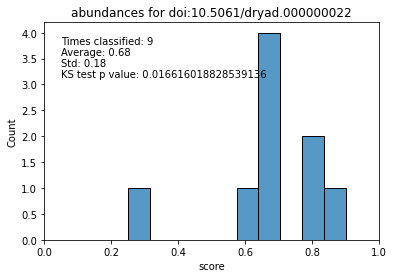

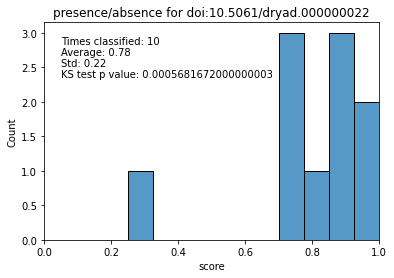

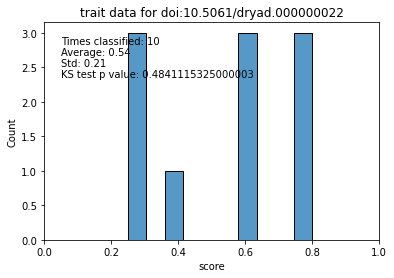

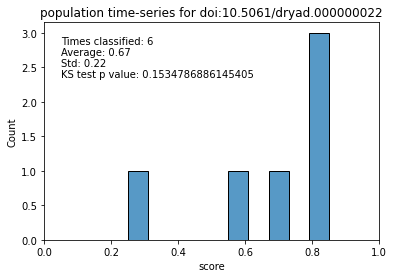

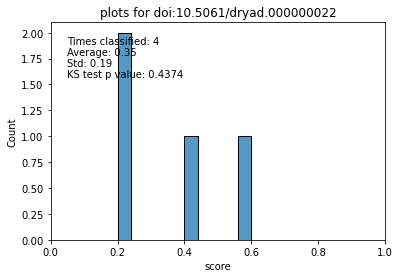

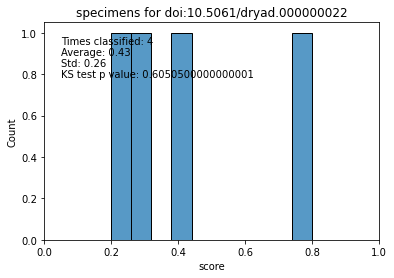

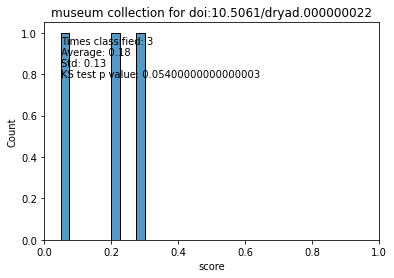

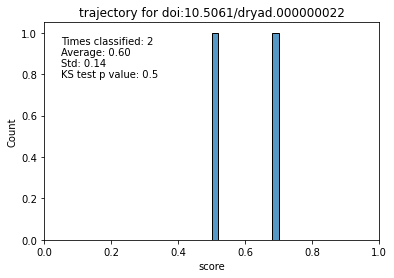

In [23]:
# For a single paper, show histograms of scores with colors by category
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kstest

doi = datasets[0]['identifier']

df_doi = df[df['doi'] == doi]

# Hists values for each category
for category in df_doi['category'].unique():
    df_category = df_doi[df_doi['category'] == category]
    sns.histplot(data=df_category, x="score", bins=10)
    plt.title(f"{category} for {doi}")
    plt.xlim(0, 1)
    # Show average and std as text in plot
    plt.text(0.05, 0.9, f"Times classified: {len(df_category)}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.85, f"Average: {df_category['score'].mean():.2f}", transform=plt.gca().transAxes)
    plt.text(0.05, 0.8, f"Std: {df_category['score'].std():.2f}", transform=plt.gca().transAxes)

    # ks test
    ks_test = kstest(df_category['score'], 'uniform')
    pvalue = ks_test.pvalue
    plt.text(0.05, 0.75, f"KS test p value: {pvalue}", transform=plt.gca().transAxes)

    plt.show()


In [24]:
# For all doi and categories, and categories, compute average, std of scores and ks test p value

doi_cat_scores_columns = ['doi', 'category', 'hallucinated', 'n', 'average', 'std', 'ks_test_pvalue', 'ci_lower_95', 'ci_upper_95']

df_doi_cat_scores = pd.DataFrame(columns = doi_cat_scores_columns)

for doi in df['doi'].unique():
    df_doi = df[df['doi'] == doi]
    for category in df_doi['category'].unique():
        hallucinated = df_doi[df_doi['category'] == category]['hallucinated'].iloc[0]
        df_category = df_doi[df_doi['category'] == category]
        average = df_category['score'].mean()
        std = df_category['score'].std()
        ks_test = kstest(df_category['score'], 'uniform')
        pvalue = ks_test.pvalue
        # 95% confidence interval using t distribution
        n = len(df_category)
        t = 2.262 # t value for 95% confidence interval with n-1 degrees of freedom
        ci_lower = average - t * std / n**0.5
        ci_upper = average + t * std / n**0.5
        df_doi_cat_scores.loc[len(df_doi_cat_scores)] = [doi, category, hallucinated, n, average, std, pvalue, ci_lower, ci_upper]

df_doi_cat_scores.head(10)

,doi,category,hallucinated,n,average,std,ks_test_pvalue,ci_lower_95,ci_upper_95
0,doi:10.5061/dryad.000000022,abundances,False,9,0.683333,0.183712,0.016616,0.544815,0.821852
1,doi:10.5061/dryad.000000022,presence/absence,False,10,0.780000,0.216282,0.000568,0.625292,0.934708
2,doi:10.5061/dryad.000000022,trait data,False,10,0.540000,0.213177,0.484112,0.387513,0.692487
3,doi:10.5061/dryad.000000022,population time-series,False,6,0.666667,0.222860,0.153479,0.460865,0.872469
4,doi:10.5061/dryad.000000022,plots,False,4,0.350000,0.191485,0.437400,0.133430,0.566570
5,doi:10.5061/dryad.000000022,specimens,False,4,0.425000,0.262996,0.605050,0.127552,0.722448
6,doi:10.5061/dryad.000000022,museum collection,False,3,0.183333,0.125831,0.054000,0.019003,0.347664
7,doi:10.5061/dryad.000000022,trajectory,False,2,0.600000,0.141421,0.500000,0.373800,0.826200
8,doi:10.5061/dryad.4767v,population time-series,False,10,0.690000,0.144914,0.007777,0.586342,0.793658
9,doi:10.5061/dryad.4767v,trait data,False,10,0.635000,0.120301,0.007777,0.548948,0.721052


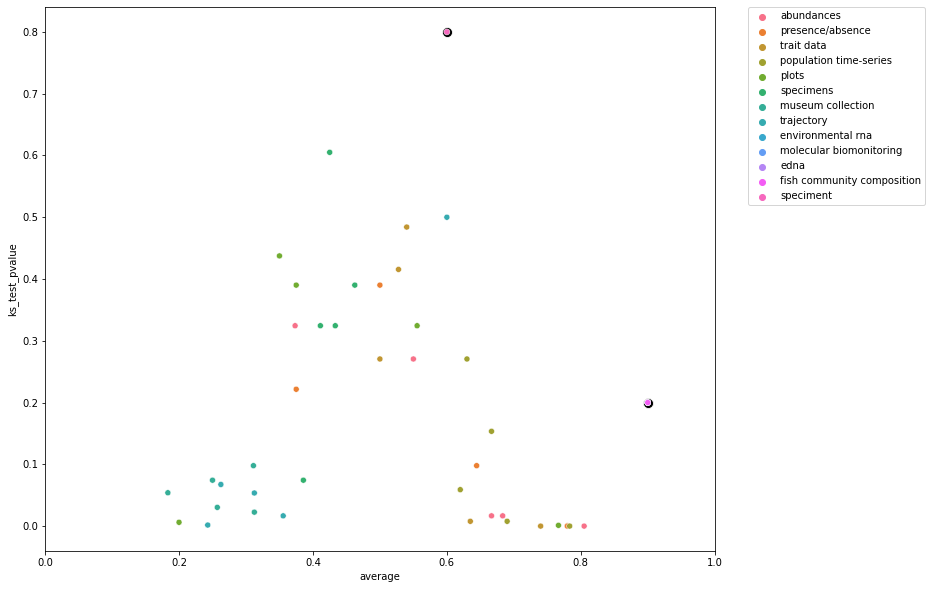

In [25]:
# Is there a correlation between the average score and the p value of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="ks_test_pvalue", color="black", marker="o", s=100)

# Use losange marker, and color by category
sns.scatterplot(data=df_doi_cat_scores, x="average", y="ks_test_pvalue", hue="category")


plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

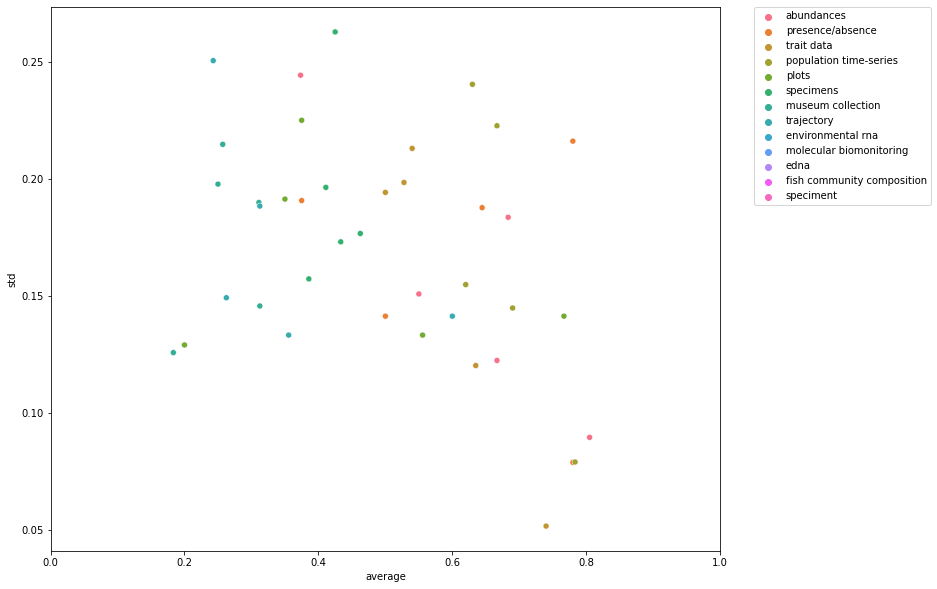

In [26]:
# Is there a correlation between the average score and the std of the ks test?
figure = plt.figure(figsize=(12, 10))

# Use slightly larger black circles around halluncinated categories
sns.scatterplot(data=df_doi_cat_scores[df_doi_cat_scores['hallucinated']], x="average", y="std", color="black", marker="o", s=100)
sns.scatterplot(data=df_doi_cat_scores, x="average", y="std", hue="category")

plt.xlim(0, 1)

# Show legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

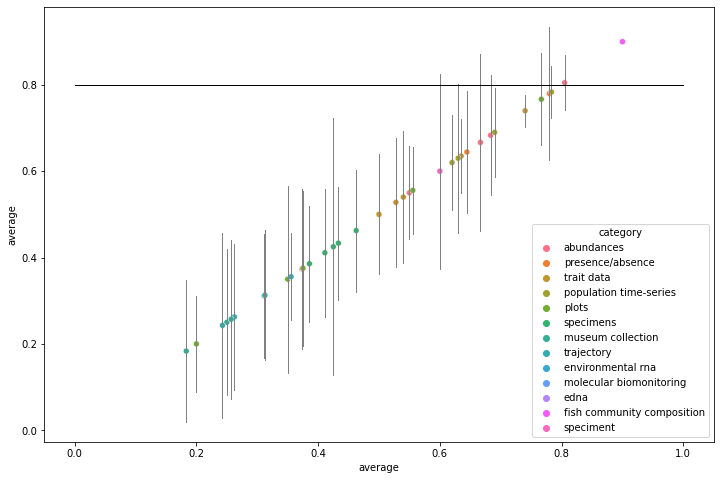

In [27]:
# Plot vertical lines for 95% confidence interval starting at (average, ci_lower) and ending at (average, ci_upper)
plt.figure(figsize=(12, 8))
for i, row in df_doi_cat_scores.iterrows():
    plt.plot([row['average'], row['average']], [row['ci_lower_95'], row['ci_upper_95']], color='grey', linestyle='-', linewidth=1)
    # Scatter plot of average average

sns.scatterplot(data=df_doi_cat_scores, x="average", y="average", hue="category")

# Horizontal line at 0.8
plt.plot([0, 1], [0.8, 0.8], color='black', linestyle='-', linewidth=1)

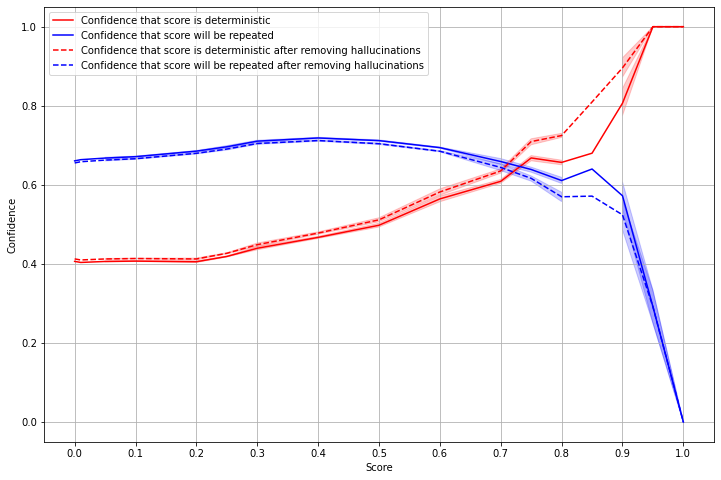

In [40]:
# What is a good threshold to choose to make sure that the classification is from a non-uniform distribution which score is close to the average

KS_THRESHOLD = 0.05
DEV_THRESHOLD = 0.15

ks_threshold_column = "confidence_threshold_ks_{}".format(str(KS_THRESHOLD).replace(".", ""))
dev_threshold_column = "confidence_dev_{}".format(str(DEV_THRESHOLD).replace(".", ""))


# Add dist_ks_pvalue to df
df["dist_ks_pvalue"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "ks_test_pvalue"]], on=["doi", "category"], how="left")["ks_test_pvalue"]
df["dist_average"] = df[["doi", "category"]].merge(df_doi_cat_scores[["doi", "category", "average"]], on=["doi", "category"], how="left")["average"]
df["deviation"] = abs(df["score"] - df["dist_average"])

# Cumulative confidence on df sorted by score
df = df.sort_values(by=["score"], ascending=False)
df.reset_index(inplace=True, drop=True)
df[f"{ks_threshold_column}"] = (df["dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{dev_threshold_column}"] = (df["deviation"] <= DEV_THRESHOLD).expanding().mean()

# Thresholds if excluding hallucinated categorie values

df.loc[df["hallucinated"] == False, f"{ks_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "dist_ks_pvalue"] <= 0.05).expanding().mean()
df[f"{ks_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)

df.loc[df["hallucinated"] == False, f"{dev_threshold_column}_no_hallucinated"] = (df.loc[df["hallucinated"] == False, "deviation"] <= DEV_THRESHOLD).expanding().mean()
df[f"{dev_threshold_column}_no_hallucinated"].fillna(method="ffill", inplace=True)


# Plot threshold curves with dashed lines for halluncinated categories and solid lines for non-hallucinated categories
# Plot blue for deviation and red for ks test
plt.figure(figsize=(12, 8))
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}", color="red", linestyle='-', label = "Confidence that score is deterministic")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}", color="blue", linestyle='-', label = "Confidence that score will be repeated")
sns.lineplot(data=df, x="score", y=f"{ks_threshold_column}_no_hallucinated", color="red", linestyle='--', label = "Confidence that score is deterministic after removing hallucinations")
sns.lineplot(data=df, x="score", y=f"{dev_threshold_column}_no_hallucinated", color="blue", linestyle='--', label = "Confidence that score will be repeated after removing hallucinations")

plt.xticks(np.arange(0, 1.1, 0.1)) #Every 0.1

# Add grid
plt.grid()

plt.xlabel("Score")
plt.ylabel("Confidence")

plt.show()


In [29]:
df.loc[df['hallucinated'] == False, 'dist_ks_pvalue']
# Alloc using .loc to avoid warning


0      0.001255
1      0.000568
2      0.000020
3      0.000568
4      0.270536
         ...   
324    0.074318
325    0.067400
326    0.324392
327    0.030322
328    0.006140
Name: dist_ks_pvalue, Length: 324, dtype: float64

In [30]:
# Sort by score and show the top 10
df.sort_values(by=['score'], ascending=False).head(20)

,doi,category,score,hallucinated,dist_ks_pvalue,dist_average,deviation,confidence_threshold_ks_005,confidence_dev_005,confidence_ks_005_no_hallucinated,confidence_dev_005_no_hallucinated
0,doi:10.5061/dryad.4767v,plots,1.00,False,0.001255,0.766667,0.233333,1.000000,0.000000,1.000000,0.0
1,doi:10.5061/dryad.000000022,presence/absence,1.00,False,0.000568,0.780000,0.220000,1.000000,0.000000,1.000000,0.0
2,doi:10.5061/dryad.4767v,abundances,0.95,False,0.000020,0.805000,0.145000,1.000000,0.000000,1.000000,0.0
3,doi:10.5061/dryad.000000022,presence/absence,0.95,False,0.000568,0.780000,0.170000,1.000000,0.000000,1.000000,0.0
14,doi:10.5061/dryad.4767v,presence/absence,0.90,False,0.000020,0.780000,0.120000,0.800000,0.066667,0.857143,0.0
23,doi:10.5061/dryad.np5hqbzvd,population time-series,0.90,False,0.270536,0.630000,0.270000,0.708333,0.166667,0.850000,0.0
21,doi:10.5061/dryad.pg4f4qrs4,environmental rna,0.90,True,0.200000,0.900000,0.000000,0.772727,0.136364,0.894737,0.0
20,doi:10.5061/dryad.pg4f4qrs4,population time-series,0.90,False,0.000061,0.783333,0.116667,0.809524,0.095238,0.894737,0.0
19,doi:10.5061/dryad.pg4f4qrs4,edna,0.90,True,0.200000,0.900000,0.000000,0.800000,0.100000,0.888889,0.0
18,doi:10.5061/dryad.4767v,abundances,0.90,False,0.000020,0.805000,0.095000,0.842105,0.052632,0.888889,0.0


In [31]:
## Question : Do halucinated classifications, presenting themselves as either typoed class names, or represents bad classification